In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import flax
import pandas as pd
import sys

sys.path.append("py-files")

In [3]:
do_64_bit = False
if do_64_bit: jax.config.update("jax_enable_x64", True)

In [4]:
import solve
import aux_ as aux
import RANK
import linear
import neural_nets
import model_funcs
import plotting

# Device

In [5]:
device = aux.choose_gpu()

Avaliable devices:


cuBLAS < 13.2 (120902 found) has a known issue where many kernels free TMEM buffers multiple times. Executing a cuBLAS kernel concurrently with another kernel (e.g. on another stream) can lead to silent data corruption.


cuda:0

Device = cuda:0 is choosen


# Load solutions

In [6]:
nn_path = 'output/final_nn.pkl'

In [7]:
model = RANK.RANK_model(device)
model.load(nn_path, opt_load=False)

In [8]:
sigma_eps_u = 0.00135
sigma_eps_z = 0.02081
sigma_eps_Gamma = 0.01278

sigma_quad = {
    "sigma_eps_u" : sigma_eps_u,
    "sigma_eps_z" :  sigma_eps_z,
    "sigma_eps_Gamma" : sigma_eps_Gamma
}

N_mc = 1_000_000

# Ergodic Mean and SSS

In [9]:
solve.compute_ergodic_dist(model, sigma_quad, 10*N_mc, do_print=True)

                               NN       OccBin
--------------------------------------------
Y (ergodic mean)           0.8569       0.8582
pi (ergodic mean)          0.1863      -0.0294
i (ergodic mean)           1.2294       1.0719
ZLB freq. (ergodic mean)       7.3720      10.1146
--------------------------------------------
Y (SSS/DSS)                0.8575       0.8589
pi (SSS/DSS)               0.1697       0.0000
i (SSS/DSS)                1.1799       1.0101


# Precision Metrics

In [10]:
linear.compute_errors(model, sigma_quad, N=N_mc)

                 Baseline       OccBin       Linear
----------------------------------------------------
Euler eq.        0.000380     0.001044     0.000739
NKPC             0.000585     0.000207     0.000018

ZLB binding      Baseline       OccBin       Linear
----------------------------------------------------
Euler eq.        0.001769     0.004919     0.005870
NKPC             0.003043     0.001213     0.000031


# Generalized Impulse Response Functions

In [11]:
solve.compute_GIRF(model, sigma_quad, N_mc, T=15, z_neg=True)

In [12]:
model.compute_IRF(sigma_quad, z_neg=True, T=15)

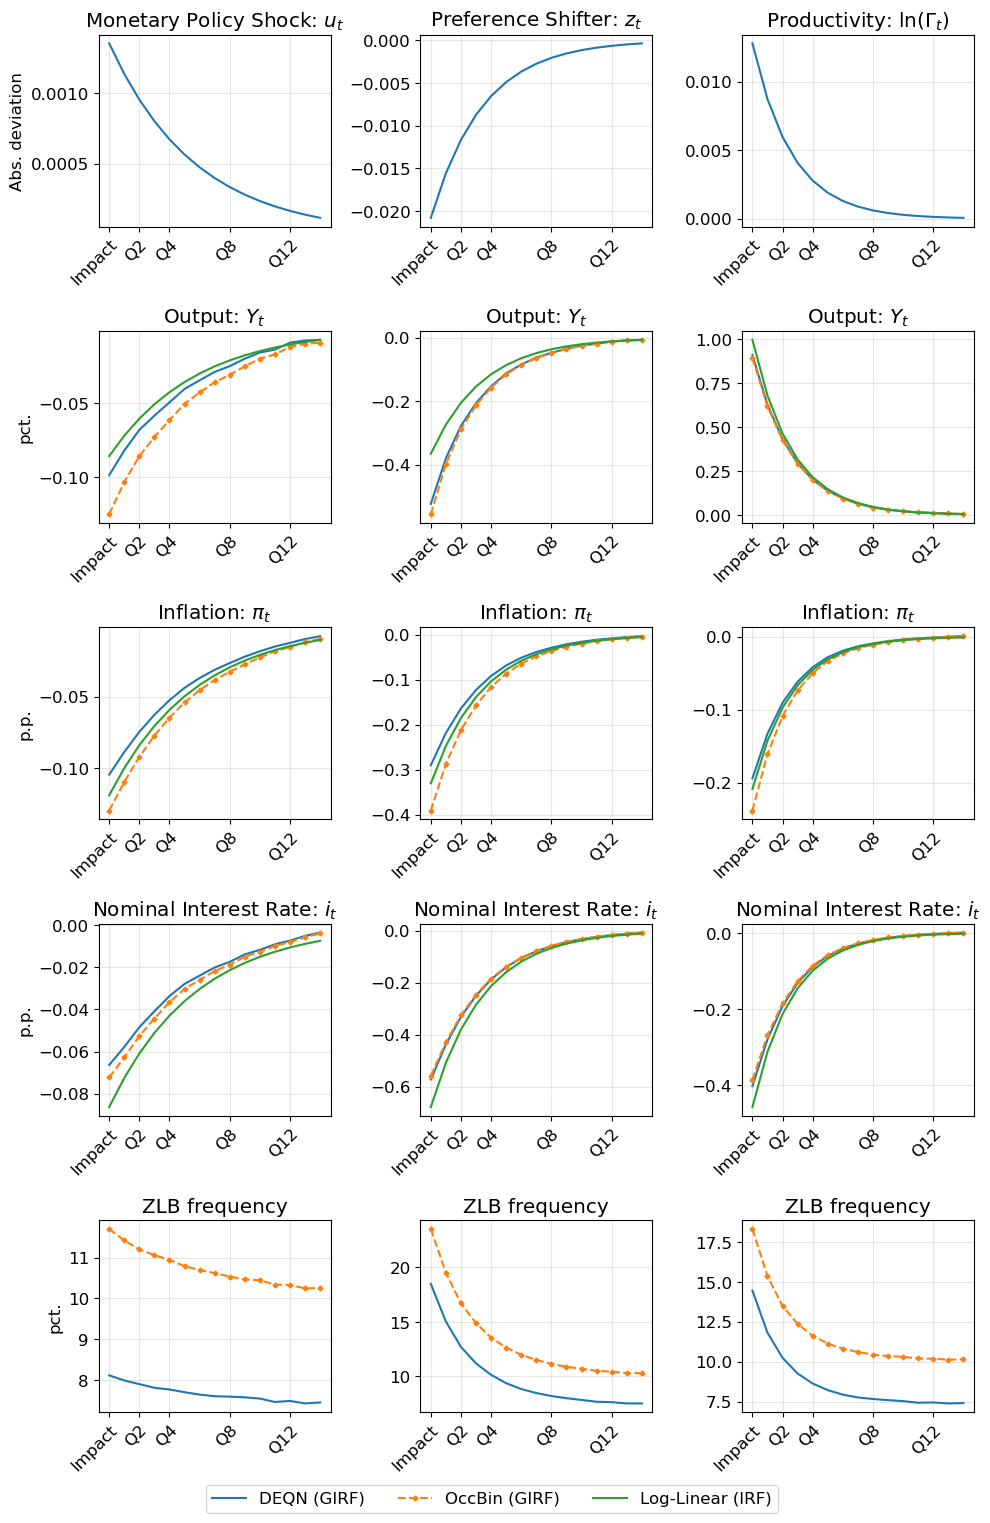

In [13]:
plotting.plot_GIRF(model, save_path='plots/GIRFs.png')

In [14]:
0.99*jnp.exp((0.7487-1)*(-0.0208))

Array(0.9951883, dtype=float32, weak_type=True)

### Values reported in the section for GIRFs

In [15]:
print(100*model.GIRF.Y_u_OccBin[0])
print(100*model.GIRF.pi_u_OccBin[0])

-0.1247796
-0.12975167


In [16]:
print(100*model.GIRF.Y_z[0])
print(100*model.GIRF.Y_z_OccBin[0])
print(100*model.IRF.Y_z_lin[0])

-0.5230467
-0.55577135
-0.3651321


In [17]:
print(100*model.GIRF.i_z_ZLB[0])
print(100*model.GIRF.i_z_ZLB_OccBin[0])

18.4925
23.53


In [18]:
print(100*model.GIRF.pi_z[0])
print(100*model.GIRF.pi_z_OccBin[0])

-0.29035395
-0.39117798


# DEQN vs. OccBin: When does the ZLB bind?

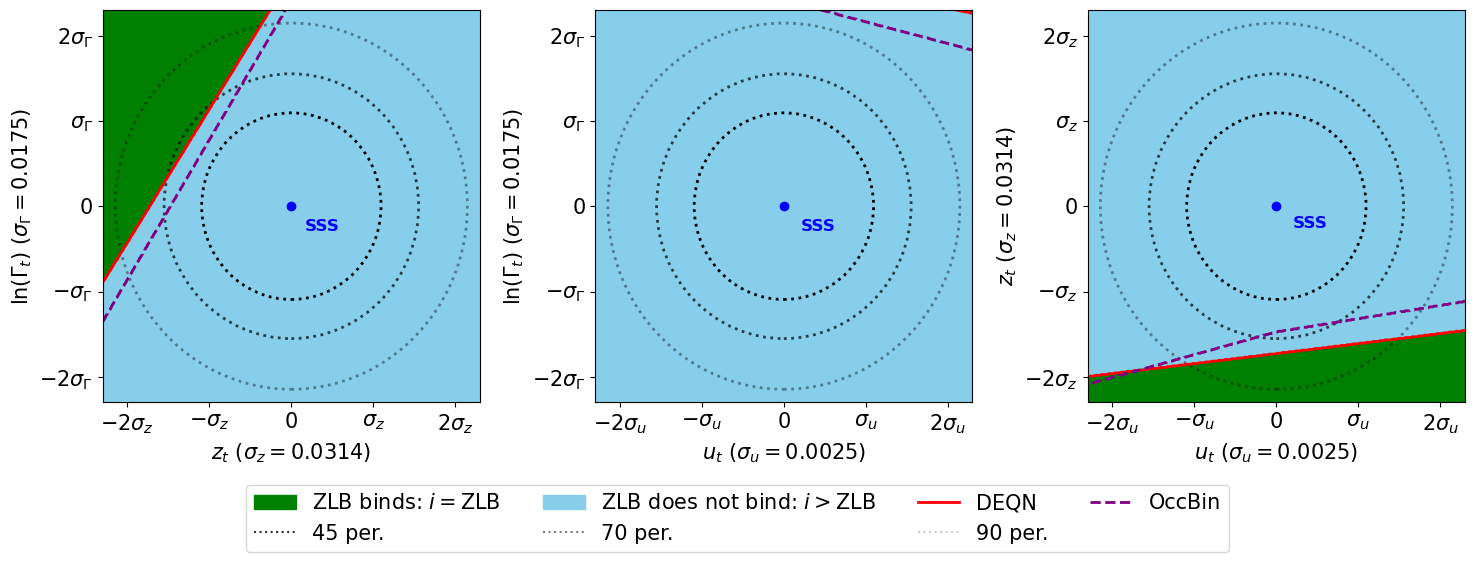

In [19]:
plotting.plot_boundaries(model, sigma_quad, N_grid=500, std_low=-2.3, std_high=2.3, save_path='plots/decision_rules.png')

# Statistics of the ZLB

In [20]:
N = 500
T = 100_000

solve.simulate(model, N, T, sigma_quad, ZLB=model.par["ZLB"], do_OccBin=True, init_SSS=False)

### Conditional probabilities

In [21]:
ZLB_dummy = model.sim.i <= -0.005 + 1e-5
ZLB_dummy_OccBin = model.sim.i_OccBin <= -0.005 + 1e-5
p_ZLB = jnp.mean(ZLB_dummy).item()
p_ZLB_OccBin = jnp.mean(ZLB_dummy_OccBin).item()

In [22]:
print(f'ZLB frequency (DEQN):\t\t{p_ZLB:.4f}')
print(f'ZLB frequency (OccBin):\t\t{p_ZLB_OccBin:.4f}')
print(f'(i<=0.0)-frequency (DEQN):\t{jnp.mean(model.sim.i <= 0.00):.4f}')
print(f'(i<=0.0)-frequency (OccBin):\t{jnp.mean(model.sim.i_OccBin <= 0.00):.4f}')

ZLB frequency (DEQN):		0.0738
ZLB frequency (OccBin):		0.1012
(i<=0.0)-frequency (DEQN):	0.1583
(i<=0.0)-frequency (OccBin):	0.2020


In [23]:
ZLB_dummies_df = pd.DataFrame(ZLB_dummy)
ZLB_dummies_df_OccBin = pd.DataFrame(ZLB_dummy_OccBin)

In [24]:
from itertools import groupby
def zlb_durations(df):
    return [
        len(list(g))
        for col in df.columns
        for k, g in groupby(df[col])
        if k == 1
    ]

all_zlb_spells = zlb_durations(ZLB_dummies_df)
all_zlb_spells_OccBin = zlb_durations(ZLB_dummies_df_OccBin)

In [25]:
all_zlb_spells_arr = jnp.array(all_zlb_spells)
unique_values, counts = jnp.unique_counts(all_zlb_spells_arr)

# frequencies
total_spells = jnp.sum(counts)
frequencies = (counts / total_spells) * 100

# print
for val, freq in zip(unique_values, frequencies):
    print(f"ZLB spell lasting {val} quarters happens {freq:.2f}% of the time")

ZLB spell lasting 1 quarters happens 58.23% of the time
ZLB spell lasting 2 quarters happens 21.23% of the time
ZLB spell lasting 3 quarters happens 9.87% of the time
ZLB spell lasting 4 quarters happens 5.02% of the time
ZLB spell lasting 5 quarters happens 2.62% of the time
ZLB spell lasting 6 quarters happens 1.40% of the time
ZLB spell lasting 7 quarters happens 0.75% of the time
ZLB spell lasting 8 quarters happens 0.40% of the time
ZLB spell lasting 9 quarters happens 0.22% of the time
ZLB spell lasting 10 quarters happens 0.12% of the time
ZLB spell lasting 11 quarters happens 0.06% of the time
ZLB spell lasting 12 quarters happens 0.04% of the time
ZLB spell lasting 13 quarters happens 0.02% of the time
ZLB spell lasting 14 quarters happens 0.01% of the time
ZLB spell lasting 15 quarters happens 0.01% of the time
ZLB spell lasting 16 quarters happens 0.00% of the time
ZLB spell lasting 17 quarters happens 0.00% of the time
ZLB spell lasting 18 quarters happens 0.00% of the time

In [26]:
all_zlb_spells_OccBin_arr = jnp.array(all_zlb_spells_OccBin)
unique_values, counts = jnp.unique_counts(all_zlb_spells_OccBin_arr)

# frequencies
total_spells = jnp.sum(counts)
frequencies = (counts / total_spells) * 100

# print
for val, freq in zip(unique_values, frequencies):
    print(f"ZLB spell lasting {val} quarters happens {freq:.2f}% of the time")

ZLB spell lasting 1 quarters happens 54.99% of the time
ZLB spell lasting 2 quarters happens 21.33% of the time
ZLB spell lasting 3 quarters happens 10.51% of the time
ZLB spell lasting 4 quarters happens 5.69% of the time
ZLB spell lasting 5 quarters happens 3.18% of the time
ZLB spell lasting 6 quarters happens 1.83% of the time
ZLB spell lasting 7 quarters happens 1.03% of the time
ZLB spell lasting 8 quarters happens 0.61% of the time
ZLB spell lasting 9 quarters happens 0.35% of the time
ZLB spell lasting 10 quarters happens 0.20% of the time
ZLB spell lasting 11 quarters happens 0.12% of the time
ZLB spell lasting 12 quarters happens 0.07% of the time
ZLB spell lasting 13 quarters happens 0.04% of the time
ZLB spell lasting 14 quarters happens 0.02% of the time
ZLB spell lasting 15 quarters happens 0.01% of the time
ZLB spell lasting 16 quarters happens 0.01% of the time
ZLB spell lasting 17 quarters happens 0.01% of the time
ZLB spell lasting 18 quarters happens 0.00% of the tim

In [27]:
print(jnp.mean(jnp.array(all_zlb_spells)))
print(jnp.mean(jnp.array(all_zlb_spells_OccBin)))

1.8520328
1.9951125


In [28]:
print(jnp.mean(jnp.array(all_zlb_spells) == 6))
print(jnp.mean(jnp.array(all_zlb_spells_OccBin) == 6))

0.013954644
0.018309118


In [29]:
zlb_1more = []
zlb_1more_OccBin = []

Tau = 12
for tau in range(1, 1+Tau):
    P_num = jnp.mean(jnp.array(all_zlb_spells) == tau + 1)
    P_denom = jnp.mean(jnp.array(all_zlb_spells) == tau)
    zlb_1more.append(P_num/P_denom)

    P_num_OccBin = jnp.mean(jnp.array(all_zlb_spells_OccBin) == tau + 1)
    P_denom_OccBin = jnp.mean(jnp.array(all_zlb_spells_OccBin) == tau)
    zlb_1more_OccBin.append(P_num_OccBin/P_denom_OccBin)

In [30]:
zlb_1more

[Array(0.3646533, dtype=float32),
 Array(0.46474403, dtype=float32),
 Array(0.50903606, dtype=float32),
 Array(0.5219004, dtype=float32),
 Array(0.5322887, dtype=float32),
 Array(0.5363493, dtype=float32),
 Array(0.53875065, dtype=float32),
 Array(0.54427695, dtype=float32),
 Array(0.53295195, dtype=float32),
 Array(0.53327614, dtype=float32),
 Array(0.5748792, dtype=float32),
 Array(0.5448179, dtype=float32)]

In [31]:
zlb_1more_OccBin

[Array(0.38787115, dtype=float32),
 Array(0.49295446, dtype=float32),
 Array(0.5411891, dtype=float32),
 Array(0.5590857, dtype=float32),
 Array(0.57552046, dtype=float32),
 Array(0.56161934, dtype=float32),
 Array(0.5890974, dtype=float32),
 Array(0.57808024, dtype=float32),
 Array(0.5689986, dtype=float32),
 Array(0.5824589, dtype=float32),
 Array(0.60910946, dtype=float32),
 Array(0.54966515, dtype=float32)]

### Conditional distributions

In [32]:
def zlb_min_spell(df, min_spell=4):
    def col_dummy(col):
        rolling_sum = col.rolling(min_spell).sum()
        return (rolling_sum == min_spell).astype(int)
    return df.apply(col_dummy, axis=0)

ZLB_4spell = zlb_min_spell(ZLB_dummies_df).to_numpy().astype(bool) # ZLB has been binding for 4 quarters or more
ZLB_4spell_OccBin = zlb_min_spell(ZLB_dummies_df_OccBin).to_numpy().astype(bool)
ZLB_6spell = zlb_min_spell(ZLB_dummies_df, min_spell=6).to_numpy().astype(bool) # ZLB has been binding for 4 quarters or more
ZLB_6spell_OccBin = zlb_min_spell(ZLB_dummies_df_OccBin, min_spell=6).to_numpy().astype(bool)

In [33]:
print(100*ZLB_4spell.mean())
print(100*ZLB_4spell_OccBin.mean())

0.9117679999999999
1.56262


In [34]:
print(100*ZLB_6spell.mean())
print(100*ZLB_6spell_OccBin.mean())

0.262054
0.516024


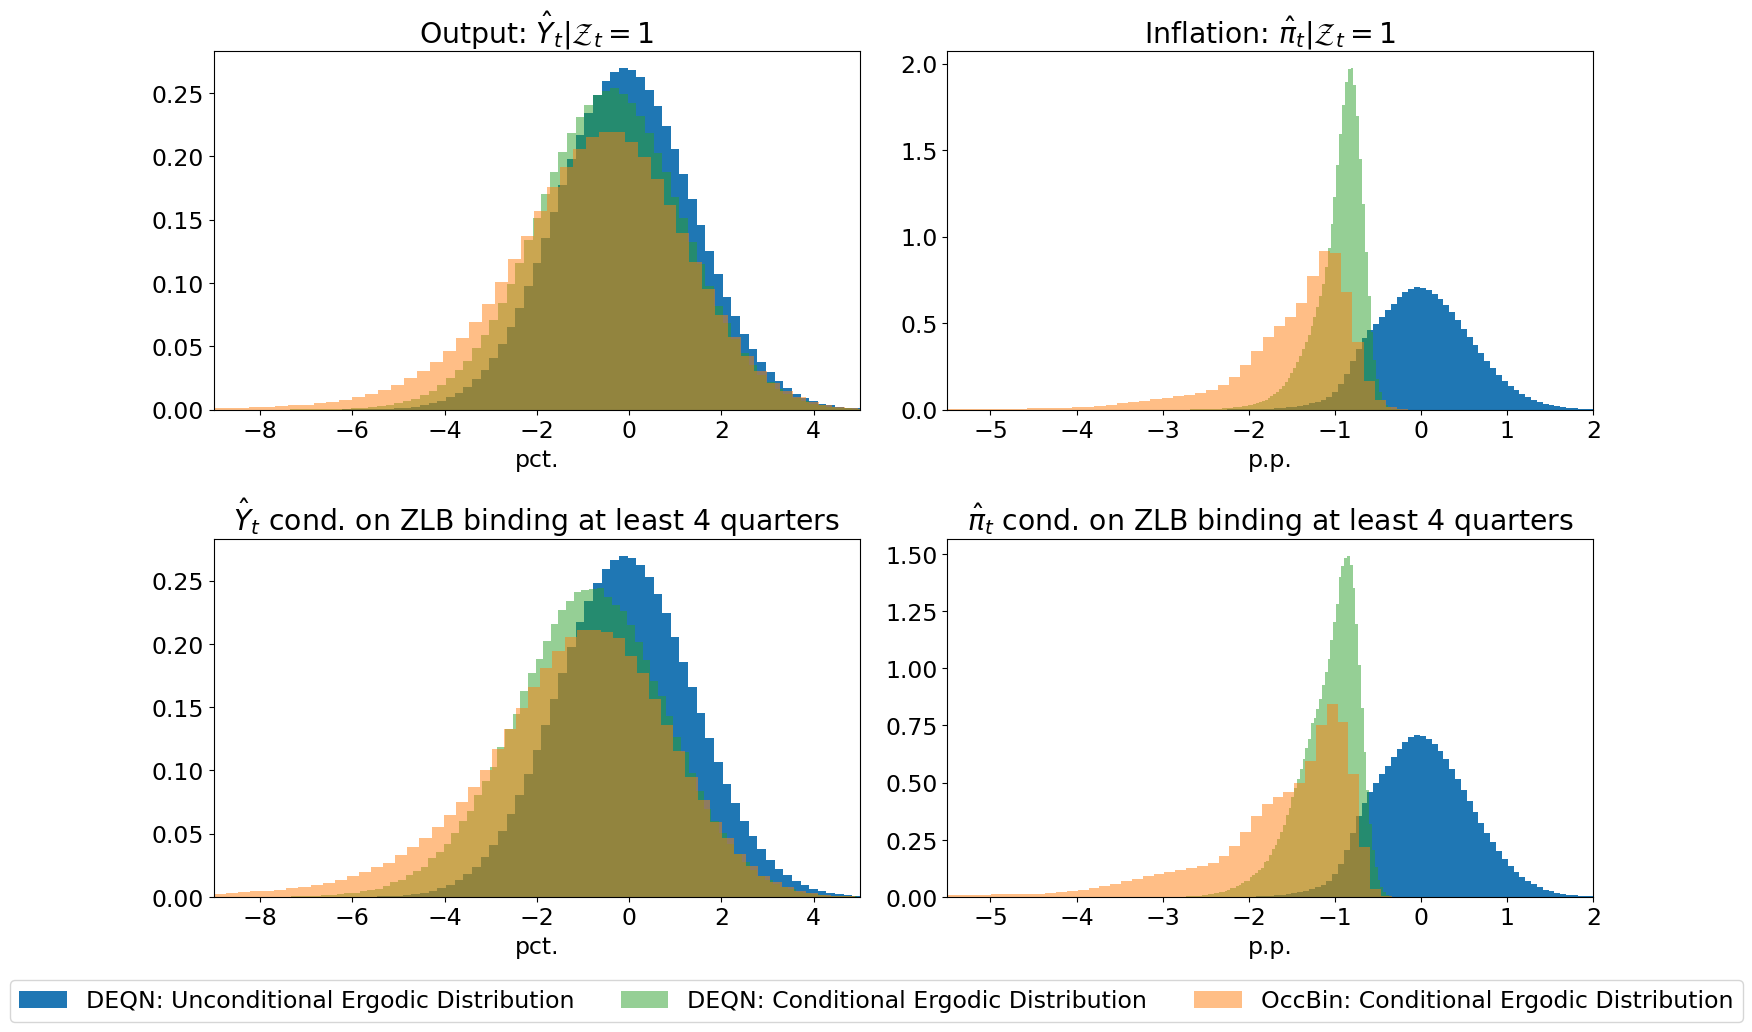

In [35]:
plt.rcParams.update({'font.size': 17})

f, ax = plt.subplots(2,2,figsize=(15,10))

ax[0,0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, color='C0', label='DEQN: Unconditional Ergodic Distribution')
ax[0,0].hist(100*model.sim.Y_dev[ZLB_dummy].flatten(), bins=100, density=True, color='C2', alpha=0.5, label='DEQN: Conditional Ergodic Distribution')
ax[0,0].hist(100*model.sim.Y_dev_OccBin[ZLB_dummy].flatten(), bins=100, density=True, color='C1', alpha=0.5, label='OccBin: Conditional Ergodic Distribution')

ax[0,1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True, color='C0')
ax[0,1].hist(100*model.sim.pi_dev[ZLB_dummy].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[0,1].hist(100*model.sim.pi_dev_OccBin[ZLB_dummy].flatten(), bins=100, density=True, color='C1', alpha=0.5)

ax[1,0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, color='C0')
ax[1,0].hist(100*model.sim.Y_dev[ZLB_4spell].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[1,0].hist(100*model.sim.Y_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, color='C1', alpha=0.5)

ax[1,1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True, color='C0')
ax[1,1].hist(100*model.sim.pi_dev[ZLB_4spell].flatten(), bins=100, density=True, color='C2', alpha=0.5)
ax[1,1].hist(100*model.sim.pi_dev_OccBin[ZLB_4spell_OccBin].flatten(), bins=100, density=True, color='C1', alpha=0.5)

for j in range(2):
    ax[j,0].set_xlim([-9, 5])
    ax[j,0].set_xlabel('pct.')
    
    ax[j,1].set_xlim([-5.5, 2])
    ax[j,1].set_xlabel('p.p.')

ax[0,0].set_title(r'Output: $\hat{Y}_t \vert \mathcal{Z}_t=1$')
ax[0,1].set_title(r'Inflation: $\hat{\pi}_t \vert \mathcal{Z}_t=1$')

ax[1,0].set_title(r'$\hat{Y}_t$ cond. on ZLB binding at least 4 quarters')
ax[1,1].set_title(r'$\hat{\pi}_t$ cond. on ZLB binding at least 4 quarters')

f.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncols=3)

f.tight_layout()

f.savefig('plots/conddist_Ypi.png', bbox_inches='tight')

In [36]:
print(100*model.sim.Y_dev[ZLB_4spell].mean())
print(100*model.sim.Y_dev_OccBin[ZLB_4spell].mean())

-0.8691205
-1.3927424


In [37]:
print(100*model.sim.pi_dev[ZLB_dummy].mean())
print(100*model.sim.pi_dev_OccBin[ZLB_dummy_OccBin].mean())

-0.9501363
-1.3475128


In [38]:
print(100*model.sim.pi_dev[ZLB_4spell].mean())
print(100*model.sim.pi_dev_OccBin[ZLB_4spell_OccBin].mean())

-1.0803525
-1.6653285


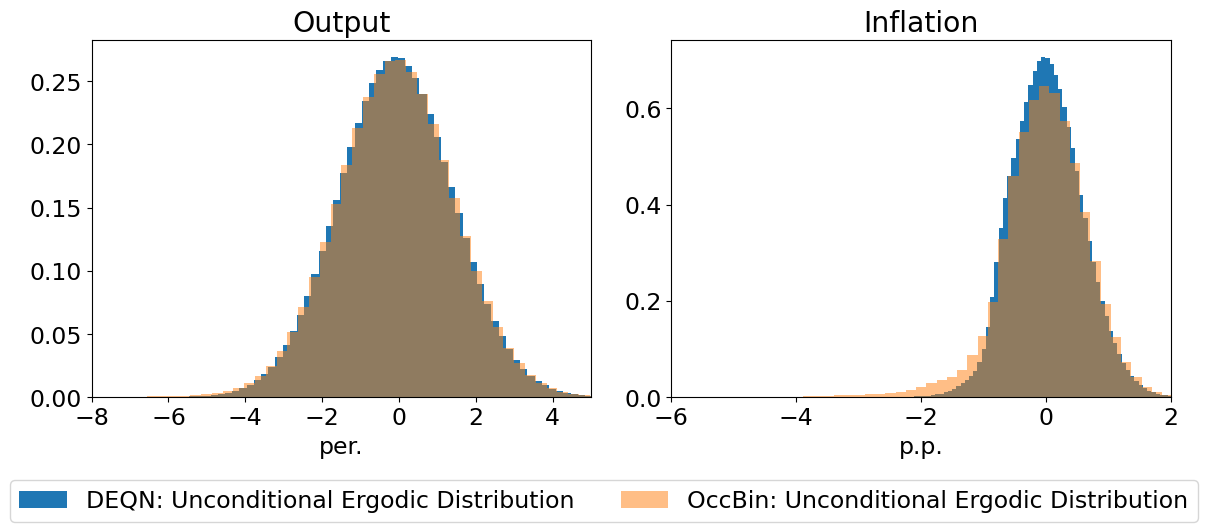

In [39]:
plt.rcParams.update({'font.size': 17})

f, ax = plt.subplots(1,2,figsize=(12,5))

ax[0].hist(100*model.sim.Y_dev.flatten(), bins=100, density=True, label='DEQN: Unconditional Ergodic Distribution')
ax[0].hist(100*model.sim.Y_dev_OccBin.flatten(), bins=100, density=True, label='OccBin: Unconditional Ergodic Distribution', alpha=0.5)

ax[1].hist(100*model.sim.pi_dev.flatten(), bins=100, density=True)
ax[1].hist(100*model.sim.pi_dev_OccBin.flatten(), bins=100, density=True, alpha=0.5)

ax[0].set_xlim([-8, 5])
ax[0].set_xlabel('per.')

ax[1].set_xlim([-6, 2])
ax[1].set_xlabel('p.p.')

ax[0].set_title('Output')
ax[1].set_title('Inflation')

f.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncols=2)

f.tight_layout()